In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import os
import plotly.graph_objects as go

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
filename = "discharge_klu.csv"
general_path = '/content/drive/My Drive/RS - IEEE - ESA/notebooks'  # ajusta la ruta
file_path = os.path.join(general_path, filename)
df = pd.read_csv(file_path, index_col='Phenomenon', parse_dates=True, skiprows=3)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1375033 entries, 2010-01-01 00:00:00+01:00 to 2025-12-31 23:59:30+01:00
Data columns (total 1 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Abfluss (m³/s)  1375033 non-null  float64
dtypes: float64(1)
memory usage: 21.0+ MB


In [60]:
df.tail(5)

,Abfluss (m³/s)
Phenomenon,
2025-12-31 23:35:00+01:00,3.60
2025-12-31 23:40:00+01:00,3.63
2025-12-31 23:55:00+01:00,3.63
2025-12-31 23:55:05+01:00,3.78
2025-12-31 23:59:30+01:00,3.82


In [61]:
df.index = pd.to_datetime(df.index, utc=True)
df_resampled = df.copy()
#df_resampled = df.resample('1h').mean()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1375033 entries, 2009-12-31 23:00:00+00:00 to 2025-12-31 22:59:30+00:00
Data columns (total 1 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Abfluss (m³/s)  1375033 non-null  float64
dtypes: float64(1)
memory usage: 21.0 MB


In [62]:
df_resampled = df_resampled.resample('15min').mean()
df_resampled.head()
# Rename a single column
df_resampled.rename(columns={'Abfluss (m³/s)': 'discharge'}, inplace=True)

In [63]:
df_resampled.head(5)

,discharge
Phenomenon,
2009-12-31 23:00:00+00:00,30.845
2009-12-31 23:15:00+00:00,30.750
2009-12-31 23:30:00+00:00,30.640
2009-12-31 23:45:00+00:00,30.590
2010-01-01 00:00:00+00:00,30.590


<Axes: >

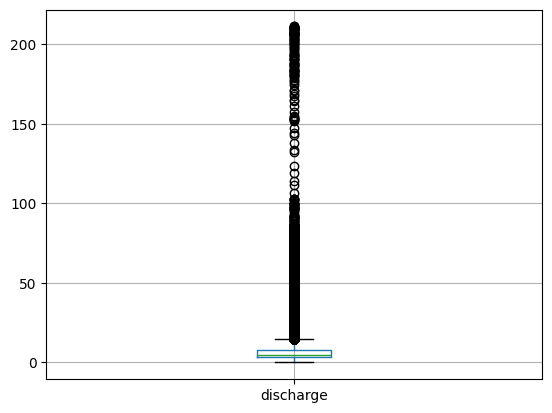

In [64]:
df_resampled.boxplot()

In [65]:
def plot_discharge(df, column='discharge', title="Discharge", warning1=None, warning2=None, save_path=None):
    """
    Simple interactive discharge plot.

    Parameters:
    - df: DataFrame with DatetimeIndex
    - column: name of discharge column (default: 'discharge')
    - title: plot title
    - warning1: first warning level value (optional)
    - warning2: second warning level value (optional)
    """
    fig = go.Figure()

    # Add discharge line
    fig.add_trace(go.Scatter(
        x=df.index,
        y=df[column],
        mode='lines',
        name='Discharge',
        line=dict(color='blue')
    ))

    # Add first warning level
    if warning1 is not None:
        fig.add_hline(
            y=warning1,
            line_dash="dash",
            line_color="orange",
            annotation_text="Warning Level 1",
            annotation_position="right"
        )

    # Add second warning level
    if warning2 is not None:
        fig.add_hline(
            y=warning2,
            line_dash="dash",
            line_color="red",
            annotation_text="Warning Level 2",
            annotation_position="right"
        )

    fig.update_layout(
        title=title,
        xaxis_title='Date',
        yaxis_title='Discharge (m³/s)',
        hovermode='x'
    )

    # Save files if path provided
    if save_path:
        fig.write_html(f"{save_path}.html")
        fig.write_image(f"{save_path}.png", width=1200, height=600)
        print(f"Saved: {save_path}.html")
        print(f"Saved: {save_path}.png")
    else:
        fig.show()
    #fig.show()
    return fig


In [20]:
plot_discharge(df_resampled, warning1=50)

Output hidden; open in https://colab.research.google.com to view.

In [66]:
def calculate_stats(df, column='discharge'):
    """
    Calculate statistics for discharge timeseries.

    Parameters:
    - df: DataFrame with DatetimeIndex
    - column: name of discharge column

    Returns:
    - Dictionary with statistics
    """
    stats = {
        'mean': df[column].mean(),
        'median': df[column].median(),
        'std': df[column].std(),
        'min': df[column].min(),
        'max': df[column].max(),
        'q25': df[column].quantile(0.25),
        'q75': df[column].quantile(0.75),
        'count': df[column].count(),
        'range': df[column].max() - df[column].min()
    }

    # Print formatted stats
    print(f"Statistics for {column}:")
    print(f"  Mean:       {stats['mean']:.2f}")
    print(f"  Median:     {stats['median']:.2f}")
    print(f"  Std Dev:    {stats['std']:.2f}")
    print(f"  Min:        {stats['min']:.2f}")
    print(f"  Max:        {stats['max']:.2f}")
    print(f"  25th %ile:  {stats['q25']:.2f}")
    print(f"  75th %ile:  {stats['q75']:.2f}")
    print(f"  Range:      {stats['range']:.2f}")
    print(f"  Count:      {stats['count']}")

    return stats


In [67]:
stats = calculate_stats(df_resampled)

Statistics for discharge:
  Mean:       8.51
  Median:     4.59
  Std Dev:    10.23
  Min:        0.00
  Max:        211.08
  25th %ile:  3.67
  75th %ile:  8.07
  Range:      211.08
  Count:      465623


In [53]:
filename_parquet = f"{filename.split('.')[0]}.parquet"
general_path_parquet = '/content/drive/My Drive/RS - IEEE - ESA/notebooks'  # ajusta la ruta
file_path_parquet = os.path.join(general_path_parquet, filename_parquet)

df_resampled = df_resampled.rename(columns={"Niederschlagshöhe (mm)": "precipitation"})
df_resampled.to_parquet(file_path_parquet)

In [68]:
df_parquet = pd.read_parquet(file_path_parquet)
df_parquet.head()

,precipitation
Phenomenon,
2019-04-19 23:15:00+00:00,0
2019-04-19 23:30:00+00:00,0
2019-04-19 23:45:00+00:00,0
2019-04-20 00:00:00+00:00,0
2019-04-20 00:15:00+00:00,0


In [69]:
df_parquet.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 96582 entries, 2019-04-19 23:15:00+00:00 to 2022-01-21 09:00:00+00:00
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   precipitation  96582 non-null  int64
dtypes: int64(1)
memory usage: 1.5 MB
